# makemore Part 5: Building a WaveNet

These exercises follow the chronological flow of the **makemore Part 5: Building a WaveNet** video and the notebook [makemore/makemore_part5_cnn1.ipynb](../makemore/makemore_part5_cnn1.ipynb). Work through them in order to re-create the notebook from scratch. The lecture takes a flat MLP character-level language model and progressively refactors it into a hierarchical, WaveNet-like architecture that fuses context in a tree-like structure.

---

## Part 1: Setup, Data, and Starter Code

### Exercise 1: Imports, Data, and Vocabulary

Write the setup code:
- Import `torch`, `torch.nn.functional as F`, and `matplotlib.pyplot as plt`. Enable inline plotting.
- Load the names file and store all words in a Python list. Print the total number of words and the maximum word length.
- Build character-level `stoi` and `itos` mappings, reserving index `0` for the special `'.'` token. Store the total number of distinct tokens as `vocab_size`.

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

bands = open('data/band_names.txt').read().splitlines()

In [2]:
chars = sorted(list(set(''.join(bands))))

stoi = {s : i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {i : s for s, i in stoi.items()}

n_chars = len(stoi)

<details><summary>💡 Solution — click to expand</summary>

```python
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('data/names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)
```

</details>

### Exercise 2: Dataset Builder with Block Size 8

Create a function `build_dataset(words)` that:
- Uses `block_size = 8` as the context window (we are scaling up from the previous block size of 3).
- Rolls a context of `[0] * block_size` through each word (including the terminating `'.'` character), appending `(context, next_char_index)` pairs to lists `X` and `Y`.
- Returns `(torch.tensor(X), torch.tensor(Y))` and prints their shapes.

Then create the 80 / 10 / 10 splits:
- Shuffle the words with `random.seed(42)` and `random.shuffle(words)`.
- Split into `Xtr/Ytr`, `Xdev/Ydev`, `Xte/Yte`.
- Print a few training examples to verify the format.

In [5]:
block_size = 8

def build_dataset(words):
    X, Y = [], []
    for word in words: 
        ctx = block_size*[0]
        for ch in word + '.':
            ix = stoi[ch]
            X.append(ctx)
            Y.append(ix)
            ctx = ctx[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(bands)

n1 = int(0.8 * len(bands))
n2 = int(0.9 * len(bands))

Xtr, Ytr = build_dataset(bands[:n1])
Xdev, Ydev = build_dataset(bands[n1:n2])
Xte, Yte = build_dataset(bands[n2:])

<details><summary>💡 Solution — click to expand</summary>

Increasing the block size from 3 to 8 means each training example now carries 8 characters of context instead of 3. The `build_dataset` function rolls a sliding window through each word exactly as before — the only change is the initial context length.

```python
block_size = 8

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])
```

Print a few examples to verify:
```python
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])
```

</details>

---

## Part 2: Layer Building Blocks

### Exercise 3: Implementing the Core Layer Classes

Implement the following layer classes, each with `__call__` (forward pass) and `parameters()` methods. These are near-copies of what was developed in Part 3, so they should feel familiar:

1. **`Linear(fan_in, fan_out, bias=True)`**: stores a weight matrix initialized with Kaiming scaling (`torch.randn / fan_in**0.5`) and an optional bias initialized to zeros. Forward pass: `x @ self.weight + self.bias`.

2. **`BatchNorm1d(dim, eps=1e-5, momentum=0.1)`**: maintains learnable `gamma` (ones) and `beta` (zeros) parameters, plus running buffers `running_mean` (zeros) and `running_var` (ones). The forward pass computes batch statistics when `self.training` is `True`, otherwise uses running buffers. **Important**: for now, compute the mean over dimension `0` only — we will fix this for 3D inputs later.

3. **`Tanh()`**: element-wise `torch.tanh(x)`. No learnable parameters.

In [39]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.training = True
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        return torch.tanh(x)

    def parameters(self):
        return []
        

In [48]:
n_embeds = 12
n_hidden = 200

g = torch.Generator().manual_seed(929350230)

C = torch.randn((n_chars, n_embeds))

layers = [
    Linear(n_embeds*block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_chars, bias = False), BatchNorm1d(n_chars)
]

with torch.no_grad():
    layers[-1].gamma *= 0.1

    for layer in layers:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum([p.nelement() for p in parameters]))

for p in parameters:
    p.requires_grad = True

154496


In [52]:
n_steps = 40000
batch_size = 128

for i in range(n_steps):

    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb = Xtr[ix]
    Yb = Ytr[ix]

    # embeddings
    X = C[Xb].view(-1, n_embeds*block_size)

    # foward pass
    for layer in layers:
        X = layer(X)
    loss = F.cross_entropy(X, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 3*n_steps/4 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 5000 == 0:
            print(f'{i}/{n_steps} : {loss.item()}')

0/40000 : 2.0600075721740723
5000/40000 : 2.1831910610198975
10000/40000 : 2.1399364471435547
15000/40000 : 1.967023253440857
20000/40000 : 1.8261293172836304
25000/40000 : 2.1395397186279297
30000/40000 : 2.1114330291748047
35000/40000 : 1.877855658531189


In [54]:
def calc_loss(split):
    x, y = {
        'train':(Xtr, Ytr),
        'dev':(Xdev, Ydev),
        'test':(Xte, Yte)
    }[split]

    x = C[x].view(-1, n_embeds*block_size)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x,y)

    print(f'{split} : {loss.item()}')

for layer in layers:
    layer.training = False

calc_loss('train')
calc_loss('dev')

train : 1.9319024085998535
dev : 1.9793604612350464


In [65]:
for _ in range(40):
    context = [0] * block_size
    band = ''

    while True:
        x = C[torch.tensor(context)].view(-1, n_embeds*block_size)
        for layer in layers:
            x = layer(x)
        probs = F.softmax(x, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        ch = itos[ix]
        band += ch

        if ch == '.':
            break

        context = context[1:] + [ix]
    print(band)

Solex.
Angermen.
Pevalation.
Coffin Light.
Dismormon.
Lord Tock.
Cadavenagy.
Apobrak.
Terra.
Graveet Remalion.
The Unred.
The Atner.
Rhoquid.
Metada.
Angel Sindication.
Isercus.
Skumper Project.
Nuckellieght.
Hellrapled.
Moon in Ascuring Inrpo.
Drazon Quimation.
Torvoer.
Hybmattere.
Angalignark.
Burgena Predatod.
Despee Sacre.
Warden.
KOperatey.
Wolfstmed.
Dilentio.
Vagender Flesh.
Plague.
HeNIre.
Immortem.
Uncozeplariuth Warfalmagerit.
Hearthed.
Potthogic.
Metalum Frosph.
Steel un.
Kamiza.


<details><summary>💡 Solution — click to expand</summary>

These are the same layers developed in Part 3, brought forward as starter code. The `Linear` layer uses Kaiming initialization (dividing by `fan_in**0.5`) to preserve the variance of activations through the layer, as discussed in the previous lecture. `BatchNorm1d` normalizes activations to zero mean and unit variance across the batch, then applies a learnable affine transform. `Tanh` is a simple element-wise nonlinearity.

```python
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []
```

</details>

### Exercise 4: Implementing `Embedding` and `FlattenConsecutive`

These two new layer classes are needed to bring the embedding lookup and the concatenation / reshape operation into our modular framework:

1. **`Embedding(num_embeddings, embedding_dim)`**: stores a weight matrix of shape `(num_embeddings, embedding_dim)`. The forward pass indexes into the weight using the input integer tensor: `self.weight[IX]`. This is equivalent to `torch.nn.Embedding`.

2. **`FlattenConsecutive(n)`**: takes a 3D input of shape `(B, T, C)` and reshapes it to `(B, T//n, C*n)`. If the resulting middle dimension is 1, squeeze it out so the output is 2D `(B, C*n)`. This is the key layer that lets us control how many consecutive character embeddings get fused at each level of the hierarchy.
   - Explain why a simple `view` operation achieves the same result as explicitly slicing even/odd positions and concatenating them (hint: think about how tensors are stored in contiguous memory).

In [67]:
class Embedding:

    def __init__(self, dim, n_embeds):
        # dim = vocab_size
        self.weight = torch.randn((dim, n_embeds))

    def __call__(self, x):
        return self.weight[x]

    def parameters(self):
        return [self.weight]


class FlattenConsecutive:

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        # B = number of batches, T = block_size (time), C = n_embeds (n_channels)
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)

        if x.shape[1] == 1:
            x = x.squeeze(1)

        return x

    def parameters(self):
        return []

<details><summary>💡 Solution — click to expand</summary>

The `Embedding` layer replaces the raw embedding table `C` we used to index manually. It wraps a weight matrix and, in its forward pass, simply indexes into it with the input integer tensor — exactly what `C[x]` does, but now packaged as a module.

`FlattenConsecutive` is the critical new layer. It reshapes a 3D tensor `(B, T, C)` into `(B, T//n, C*n)`. For example, with `n=2` and an input of shape `(4, 8, 10)`, it produces `(4, 4, 20)`: every pair of consecutive 10-d embeddings is concatenated into a 20-d vector. The reason a simple `view` works (instead of explicit slicing and `torch.cat`) is that PyTorch tensors are stored in row-major (C-contiguous) order. The 10-d vectors for characters 0 and 1 are already adjacent in memory, so reshaping from `(8, 10)` to `(4, 20)` naturally places them side-by-side — no data movement is needed.

```python
class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]


class FlattenConsecutive:

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []
```

</details>

### Exercise 5: Implementing `Sequential`

Implement a `Sequential` container class:
- `__init__` takes a list of layers and stores it.
- `__call__` feeds the input through each layer in order and returns the final output.
- `parameters()` collects and returns parameters from all child layers as a flat list.

This is equivalent to `torch.nn.Sequential`.

In [73]:
class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

<details><summary>💡 Solution — click to expand</summary>

The `Sequential` container is a simple but powerful abstraction. It stores a list of layers and, on each forward call, passes the input through every layer in order. This is exactly what `torch.nn.Sequential` does. It lets us treat an entire network as a single callable object.

```python
class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
```

</details>

---

## Part 3: Flat Baseline — Block Size 8

### Exercise 6: Building and Training the Flat Model

Assemble a flat (non-hierarchical) model that crushes all 8 context characters into a single hidden layer:
- Set `n_embd = 10`, `n_hidden = 200`.
- Seed with `torch.manual_seed(42)`.
- Build a `Sequential` model with:
  - `Embedding(vocab_size, n_embd)`
  - `FlattenConsecutive(8)` — flattens all 8 embeddings into one vector of length 80
  - `Linear(n_embd * 8, n_hidden, bias=False)`, `BatchNorm1d(n_hidden)`, `Tanh()`
  - `Linear(n_hidden, vocab_size)`
- Scale the last layer's weight by `0.1` to avoid overconfident initialization.
- Print the total number of parameters.
- Train for 200,000 steps (batch size 32, lr=0.1 for the first 150,000 steps, then 0.01).
- Plot the smoothed loss curve (view the log₁₀ losses as groups of 1,000 and take their mean).
- Evaluate train/val loss. You should get roughly **val ≈ 2.02–2.03**.

Explain why simply increasing the context from 3 to 8 already improves performance compared to the Part 3 model, even though the architecture is not yet hierarchical.

In [95]:
model = Sequential([
    Embedding(n_chars, n_embeds),
    FlattenConsecutive(block_size),
    Linear(n_embeds*block_size, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_chars, bias = False), BatchNorm1d(n_chars)
])

with torch.no_grad():
    model.layers[-1].gamma *= 0.1

    for layer in model.layers:
            if isinstance(layer, Linear):
                layer.weight *= 5/3

print(sum([p.nelement() for p in model.parameters()]))

for p in model.parameters():
    p.requires_grad = True


154496


In [99]:
max_iter = 40000
batch_size = 128
lossi = []

for i in range(max_iter):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    logits = model(Xtr[ix])
    loss = F.cross_entropy(logits, Ytr[ix])

    for p in model.parameters():
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 3/4*max_iter else 0.01
    for p in model.parameters():
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())

    if i % 5000 == 0:
        print(f'{i:7d} / {max_iter:7d}: {loss.item():.4f}')

      0 /   40000: 2.0835
   5000 /   40000: 2.0664
  10000 /   40000: 1.9368
  15000 /   40000: 1.9203
  20000 /   40000: 1.9979
  25000 /   40000: 1.9821
  30000 /   40000: 1.8232
  35000 /   40000: 1.7282


In [100]:
@torch.no_grad()
def calc_loss(split):
    x, y = {
        'train':(Xtr, Ytr),
        'dev':(Xdev, Ydev),
        'test':(Xte, Yte)
    }[split]

    x = model(x)
    loss = F.cross_entropy(x,y)

    print(f'{split} : {loss.item():.4f}')

for layer in model.layers:
    layer.training = False

calc_loss('train')
calc_loss('dev')


train : 1.8578
dev : 1.9273


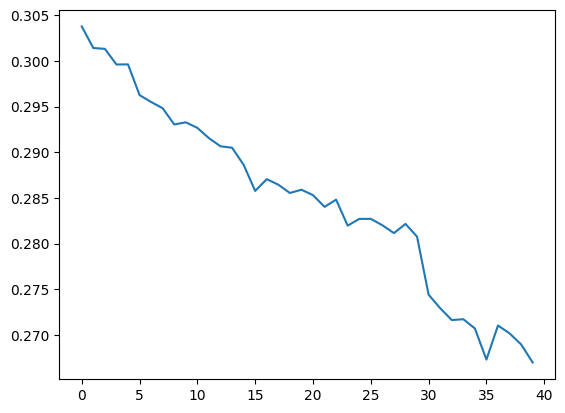

In [101]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [102]:
for _ in range(40):
    context = [0] * block_size
    band = ''

    while True:
        x = model(torch.tensor([context]))
        probs = F.softmax(x, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        ch = itos[ix]
        band += ch

        if ch == '.':
            break

        context = context[1:] + [ix]
    print(band)


Agathate.
Ution.
Sulvarium.
RyWikla.
War and Misery.
Shreda Christ.
Black Viton.
Gilyters.
Temple God.
Serapom.
Sanctumes.
Atamaty.
Trepit.
Abstraad Asgeb.
Fulchrus.
Graveous Munior.
Diable of Death.
Chaos of Hair.
Embrya.
Perfect Dawn.
Zhe Habia.
Icon.
Celahile.
Bephara.
Hellny.
Dusciphi.
Dimletscrown.
Warzes of Voice.
Morphago.
Skulf.
HrCLust Brila.
Rifeless Devil Raiser.
Parum.
Destiny.
Enustrum Mu Valis.
Jaricor Animony.
Obrudeen.
Hellgracord.
Blue Corrupt.
Stage.


<details><summary>💡 Solution — click to expand</summary>

Increasing the context length from 3 to 8 gives the model access to more history when predicting the next character. Even with a flat architecture that crushes all 8 embeddings into one hidden layer, the additional context helps because longer-range patterns (like common 4- or 5-letter prefixes) become visible. The model moves from val 2.10 to roughly val 2.03 just from this change.

**Model definition:**
```python
torch.manual_seed(42)

n_embd = 10
n_hidden = 200

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(8),
    Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True
```

**Training loop:**
```python
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
```

**Plot and evaluate:**
```python
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
```

```python
for layer in model.layers:
    layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
```

</details>

---

## Part 4: The WaveNet Idea — Hierarchical Fusion

### Exercise 7: Understanding the WaveNet Architecture

Before writing any code, answer the following conceptual questions about the WaveNet architecture, drawing on the lecture and the original 2016 DeepMind paper:

1. **What problem does the flat MLP have?** The flat model concatenates all 8 character embeddings into an 80-dimensional vector and immediately passes it through a single hidden layer. Why is this "squashing too much information too quickly"? What is lost compared to a deeper architecture?

2. **What is the tree-like / hierarchical fusion structure?** Describe the architecture in plain language:
   - At the first level, pairs of consecutive characters are fused (bigrams).
   - At the second level, pairs of bigram representations are fused (4-grams).
   - At the third level, pairs of 4-gram representations are fused (8-grams), producing a single vector that feeds into the output layer.
   - Draw a simple ASCII diagram of this tree for 8 input characters.

3. **Why does this work better in principle?** The hierarchical model has the same number of parameters as the flat model (when tuned appropriately), but the parameters are distributed across multiple layers that each do a smaller, more focused job. Each layer only needs to learn how to combine two adjacent representations — a much simpler function than learning to combine all 8 at once. The network can build up increasingly abstract features at each level.

4. **What is a "dilated causal convolution" and how does it relate to what we're building?** The WaveNet paper describes its architecture using dilated causal convolutions. Explain that:
   - "Causal" means each output only depends on current and past inputs (no future information leaks in), which is required for autoregressive generation.
   - "Dilated" means the convolution skips over inputs at increasing intervals (dilation 1, 2, 4, ...), which is how the receptive field grows exponentially — exactly matching our tree structure.
   - The convolution is really just an efficient implementation of the same tree-like computation we're building by hand. Instead of a Python for-loop over positions, a 1D convolution slides a linear filter over the sequence in optimized CUDA kernels.

5. **What does the WaveNet architecture diagram mean?** In the paper's figure, the bottom row shows input nodes. Each subsequent row applies a dilated convolution: dilation 1 fuses pairs at distance 1, dilation 2 fuses pairs at distance 2, dilation 4 fuses pairs at distance 4. The highlighted black tree shows the receptive field of a single output — it is exactly the tree we described. The key insight is that the same filter weights are shared across all positions (weight sharing), and intermediate computations are reused between overlapping receptive fields (the orange nodes), making convolutions far more efficient than our naive for-loop approach.

In [ ]:
# Exercise 7: Your answers here (use comments or markdown in a separate cell)


<details><summary>💡 Solution — click to expand</summary>

**1. The problem with the flat MLP.** When all 8 character embeddings (80 numbers) are concatenated and fed into a single hidden layer, the linear layer must learn — in one step — how every combination of all 8 characters relates to the output. This is an extremely high-dimensional function. Most of that 80-dimensional space is wasted: the model cannot specialize parts of the computation to local patterns (like common bigrams or trigrams). It's analogous to reading an entire sentence in one glance rather than reading words, then phrases, then clauses — the one-shot approach is possible but much harder to learn.

**2. The tree-like hierarchical structure.** The idea is to fuse information gradually:

```
Level 0 (input):     c0   c1   c2   c3   c4   c5   c6   c7      (8 characters)
                      \  /      \  /      \  /      \  /
Level 1 (bigrams):    b01      b23       b45       b67            (4 bigram reps)
                       \      /           \       /
Level 2 (4-grams):     q0123            q4567                    (2 four-gram reps)
                          \             /
Level 3 (8-gram):         representation                         (1 full-context rep)
                               |
                           output logits
```

At each level, only two adjacent representations are combined. The linear layers at each level need to learn a much simpler function: "how to combine two things" rather than "how to combine eight things."

**3. Why it works better.** The hierarchical model distributes its parameters across three layers instead of one. Each layer learns a simpler mapping (combining two representations into one), and the network can build up increasingly abstract features: character pairs → short subsequences → the full context. This is the same principle behind deep networks in general — depth enables compositional feature learning that width alone cannot efficiently replicate.

**4. Dilated causal convolutions.** In the WaveNet paper, the tree structure is implemented using dilated causal convolutions:
- *Causal*: the filter only looks at current and past positions — no future information leaks in. This is essential for autoregressive generation where we predict the next token given only the past.
- *Dilated*: the convolution filter skips over inputs at exponentially increasing intervals. At layer 1, the dilation is 1 (adjacent characters). At layer 2, the dilation is 2 (every other bigram representation). At layer 3, the dilation is 4. This is exactly how our tree structure works — each level doubles the spacing.
- The convolution is strictly an efficiency optimization. It doesn't change the mathematical computation — it just implements the same tree-like sliding in fast, parallelized CUDA kernels instead of a Python for-loop.

**5. Reading the WaveNet diagram.** The diagram's bottom row is the input sequence. Each subsequent row is a convolutional layer with increasing dilation. The highlighted black tree shows the receptive field of one output position — it covers 8 input positions through 3 layers of dilation (1, 2, 4). The crucial detail is that adjacent output positions have overlapping receptive fields, so many intermediate nodes (the orange ones) are shared. A convolution computes all these intermediate values at every position in a single batched operation, avoiding redundant computation. In our manual implementation, forwarding each position independently would recompute these shared nodes — convolutions avoid that.

</details>

### Exercise 8: Building the Hierarchical Model

Now implement the hierarchical architecture:
- Use `n_embd = 10`, `n_hidden = 68` (chosen so the total parameter count roughly matches the flat model at ~22,000).
- Seed with `torch.manual_seed(42)`.
- Build a `Sequential` model with three fusion stages:
  ```
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
  ```
- Scale the last layer's weight by `0.1`.
- Inspect the shapes through the network by running a small test batch (4 examples) and printing the output shape after each layer. Verify the progressive fusion:
  - After `Embedding`: `(4, 8, 10)` — 8 characters, each a 10-d vector.
  - After first `FlattenConsecutive(2)`: `(4, 4, 20)` — 4 bigram groups, each 20-d.
  - After first `Linear`: `(4, 4, 68)` — projected to hidden size.
  - After second `FlattenConsecutive(2)`: `(4, 2, 136)` — 2 four-gram groups.
  - After second `Linear`: `(4, 2, 68)`.
  - After third `FlattenConsecutive(2)`: `(4, 136)` — single 8-gram, squeezed to 2D.
  - After third `Linear`: `(4, 68)`.
  - Final `Linear`: `(4, 27)` — logits over the vocabulary.

In [122]:
model = Sequential([
    Embedding(n_chars, n_embeds),
    FlattenConsecutive(2), Linear(n_embeds * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_chars, bias = False), BatchNorm1d(n_chars)
])

with torch.no_grad():
    model.layers[-1].gamma *= 0.1   

    for layer in model.layers:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = model.parameters()
print(sum([p.nelement() for p in parameters]))

for p in parameters:
    p.requires_grad = True


179696


In [ ]:
ix = torch.randint(0, Xtr.shape[0], (1,))
x = Xtr[ix]

print(f'Input : {x.shape}')
for layer in model.layers:
    x = layer(x)
    print(f'{layer.__class__.__name__} : {x.shape}')

# Input : (1, 8)
# Embedding : (1, 8, 12)
# FlattenConsecutive (1, 4, 24) 
# Linear (1, 4, 200) 
# BatchNorm (1, 4, 200)
# FlattenConsecutive (1, 2, 400) 
# Linear (1, 2, 200)
# BatchNorm (1, 2, 200)
# FlattenConsecutive (1, 400)
# Linear (1, 200)
# BatchNorm (1, 200)
# Linear (1, 64)

Input : torch.Size([1, 8])
Embedding : torch.Size([1, 8, 12])
FlattenConsecutive : torch.Size([1, 4, 24])
Linear : torch.Size([1, 4, 200])
BatchNorm1d : torch.Size([1, 4, 200])
Tanh : torch.Size([1, 4, 200])
FlattenConsecutive : torch.Size([1, 2, 400])
Linear : torch.Size([1, 2, 200])
BatchNorm1d : torch.Size([1, 2, 200])
Tanh : torch.Size([1, 2, 200])
FlattenConsecutive : torch.Size([1, 400])
Linear : torch.Size([1, 200])
BatchNorm1d : torch.Size([1, 200])
Tanh : torch.Size([1, 200])
Linear : torch.Size([1, 64])
BatchNorm1d : torch.Size([1, 64])


C:\Users\I0567922\AppData\Local\Temp\ipykernel_38024\2629736066.py:31: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1823.)
  xvar = x.var(0, keepdim=True)


<details><summary>💡 Solution — click to expand</summary>

With `n_hidden = 68`, the hierarchical model has roughly the same number of parameters (~22K) as the flat model, allowing a fair comparison. The three `FlattenConsecutive(2)` layers progressively halve the sequence length while doubling the feature dimension, and the `Linear` layers project back to `n_hidden`.

The matrix multiply inside `Linear` naturally handles 3D inputs. PyTorch applies the matrix multiplication only on the last dimension, treating all preceding dimensions as batch dimensions. This means a `(4, 4, 20) @ (20, 68)` multiplication produces `(4, 4, 68)` — each of the 4 bigram groups is processed independently and in parallel.

**Model definition:**
```python
torch.manual_seed(42)

n_embd = 10
n_hidden = 68

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2,   n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2,  n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2,  n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True
```

**Inspect shapes:**
```python
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb = Xtr[ix]
x = Xb
for layer in model.layers:
    x = layer(x)
    print(layer.__class__.__name__, x.shape)
```

Expected output:
```
Embedding         torch.Size([4, 8, 10])
FlattenConsecutive torch.Size([4, 4, 20])
Linear            torch.Size([4, 4, 68])
BatchNorm1d       torch.Size([4, 4, 68])
Tanh              torch.Size([4, 4, 68])
FlattenConsecutive torch.Size([4, 2, 136])
Linear            torch.Size([4, 2, 68])
BatchNorm1d       torch.Size([4, 2, 68])
Tanh              torch.Size([4, 2, 68])
FlattenConsecutive torch.Size([4, 136])
Linear            torch.Size([4, 68])
BatchNorm1d       torch.Size([4, 68])
Tanh              torch.Size([4, 68])
Linear            torch.Size([4, 27])
```

</details>

### Exercise 9: Training and Comparing Performance

Train the hierarchical model for 200,000 steps with the same training loop as Exercise 6. Evaluate train/val loss. You should get roughly **val ≈ 2.03** — essentially the same as the flat model.

Explain why the performance is roughly identical at this small scale: with only 22K parameters and relatively little tuning, the architecture change alone doesn't shine. The benefit of the hierarchical structure becomes more apparent when scaling up.

In [126]:
max_iter = 80000
batch_size = 128
#lossi = []

for i in range(max_iter):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    logits = model(Xtr[ix])
    loss = F.cross_entropy(logits, Ytr[ix])

    for p in model.parameters():
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 3/4*max_iter else 0.01
    for p in model.parameters():
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())

    if i % 5000 == 0:
        print(f'{i:7d} / {max_iter:7d}: {loss.item():.4f}')

      0 /   80000: 2.0668
   5000 /   80000: 1.9556
  10000 /   80000: 2.1127
  15000 /   80000: 1.8945
  20000 /   80000: 1.9290
  25000 /   80000: 1.8263
  30000 /   80000: 2.0180
  35000 /   80000: 1.9905
  40000 /   80000: 1.7511
  45000 /   80000: 2.0231
  50000 /   80000: 1.9634
  55000 /   80000: 1.9737
  60000 /   80000: 1.9297
  65000 /   80000: 1.6700
  70000 /   80000: 1.8735
  75000 /   80000: 1.8807


train : 1.7988
dev : 1.8934


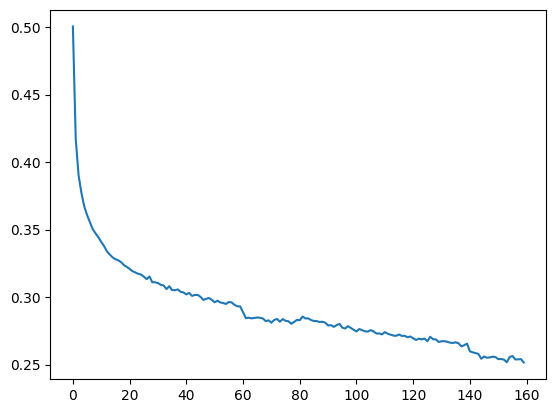

In [127]:
@torch.no_grad()
def calc_loss(split):
    x, y = {
        'train':(Xtr, Ytr),
        'dev':(Xdev, Ydev),
        'test':(Xte, Yte)
    }[split]

    x = model(x)
    loss = F.cross_entropy(x,y)

    print(f'{split} : {loss.item():.4f}')

for layer in model.layers:
    layer.training = False

calc_loss('train')
calc_loss('dev')

plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))


In [128]:
for _ in range(40):
    context = [0] * block_size
    band = ''

    while True:
        x = model(torch.tensor([context]))
        probs = F.softmax(x, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        ch = itos[ix]
        band += ch

        if ch == '.':
            break

        context = context[1:] + [ix]
    print(band)

Raptocracy.
Heaven NIIll.
Hideouss.
No Polation.
King Klash.
Throne.
Funhanged in Age Sorwasured Sacuia.
Terroral Thieph.
Essent the Abyss.
Comp6rode.
Zarasuge.
Docker Leagon.
Bestial Clounds.
Solisma Crescos.
Nasnery Holo.
Kennaldust.
The Skylung.
Obscure Project.
Undergadu.
Sepression.
Aura Last Naoro.
Death Jouts.
Parastatic Human Night.
Orizen.
Virum.
Magnaved.
The Shardlynnucifer.
HoudSoul.
Christice.
Three Vengeon.
Idole.
Dispell.
Gehuman Fire.
Dimension.
Hellfire.
Horna.
Sinnernal.
Kimberminal Day.
Hallen.
Eden of Age6.


<details><summary>💡 Solution — click to expand</summary>

At ~22K parameters, the hierarchical model gets roughly val ≈ 2.03, essentially identical to the flat model. This is expected: at this small scale with a first-guess hyperparameter setting, the architectural advantage of hierarchical fusion is marginal. The benefit shows when we scale up (more parameters, larger embeddings) and when we properly tune the channel allocation across layers.

```python
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
```

```python
for layer in model.layers:
    layer.training = False

split_loss('train')
split_loss('val')
```

</details>

---

## Part 5: Fixing BatchNorm for 3D Inputs

### Exercise 10: Diagnosing the BatchNorm Bug

The `BatchNorm1d` layer we wrote in Part 3 was designed for 2D inputs `(N, C)`. But in our hierarchical model, the intermediate tensors are 3D `(B, T, C)` where `T` is the number of groups at that level.

Investigate what happens with the current implementation:
- After training the hierarchical model, inspect the `running_mean` shape of the first `BatchNorm1d` layer (e.g., `model.layers[3]`).
- You should find it is `(1, 4, 68)` instead of the expected `(1, 1, 68)` or just `(68,)`.

Explain the bug:
- `x.mean(0, keepdim=True)` on a `(32, 4, 68)` tensor reduces only over the batch dimension, yielding `(1, 4, 68)`. This means the layer maintains *separate* statistics for each of the 4 positions — 4 × 68 = 272 means/variances instead of just 68.
- This is wrong because we want position-invariant normalization: the same channel statistics regardless of which "group" position the activation came from.
- The practical consequence is that each mean/variance estimate is computed from only 32 numbers (the batch size) instead of 32 × 4 = 128, making the estimates noisier and less stable.

In [ ]:
print(model.layers[3].running_mean.shape)

<details><summary>💡 Solution — click to expand</summary>

When `BatchNorm1d` receives a 3D input of shape `(32, 4, 68)` and computes `x.mean(0, keepdim=True)`, it reduces only over the batch dimension (axis 0), producing a tensor of shape `(1, 4, 68)`. This means the layer maintains 4 separate means and variances for each of the 68 channels — one per group position. This is incorrect because:

- The groups at positions 0, 1, 2, 3 are all processed by the same linear layer with the same weights. They represent the same kind of feature, just at different positions in the sequence.
- Each mean/variance is estimated from only 32 samples (the batch size) instead of 32 × 4 = 128 samples, making the estimates noisier.
- The running statistics will have shape `(1, 4, 68)` — 272 values — instead of `(1, 1, 68)` — 68 values.

```python
# After training the hierarchical model, inspect:
print(model.layers[3].running_mean.shape)  # BatchNorm1d after first Linear
# Expect: torch.Size([1, 4, 68]) -- this is the bug!
```

</details>

### Exercise 11: Fixing BatchNorm to Reduce over Multiple Dimensions

Update the `BatchNorm1d.__call__` method:
- Check `x.ndim`: if it is 2, reduce over dimension `0`; if it is 3, reduce over dimensions `(0, 1)`.
- Use `torch.mean` and `torch.var` with a tuple of dimensions.
- Raise an error if `x.ndim` is anything else.

After the fix:
- Re-initialize and retrain the hierarchical model.
- Verify the `running_mean` shape is now `(1, 1, 68)`.
- The validation loss should improve slightly (from ~2.029 to ~2.022) because the statistics are now estimated more accurately.

Note on PyTorch's convention: `torch.nn.BatchNorm1d` expects inputs as `(N, C)` or `(N, C, L)` — channels second. Our implementation uses channels-last `(N, L, C)`, which is a deliberate design choice.

In [129]:
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.training = True
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dims = 0
            elif x.ndim == 3:
                dims = (0,1)
            else:
                raise ValueError(f'Expected 2D or 3D input. Got {x.ndim}D.')
            xmean = x.mean(dims, keepdim=True)
            xvar = x.var(dims, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

<details><summary>💡 Solution — click to expand</summary>

The fix is straightforward: when the input is 3D, reduce over both dimension 0 (batch) and dimension 1 (groups/positions). PyTorch's `torch.mean` and `torch.var` accept a tuple of dimensions.

Note: PyTorch's `torch.nn.BatchNorm1d` expects 3D inputs as `(N, C, L)` — channels in the middle — and reduces over `(0, 2)`. Our implementation uses channels-last format `(N, L, C)` and reduces over `(0, 1)`. Both are valid; channels-last is arguably more natural for sequence models.

```python
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            else:
                raise ValueError(f"Expected 2D or 3D input, got {x.ndim}D")
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]
```

After retraining with this fix:
```python
print(model.layers[3].running_mean.shape)  # Now: torch.Size([1, 1, 68]) -- correct!
```

The validation loss improves slightly from ~2.029 to ~2.022. The improvement comes from the more stable mean/variance estimates: 128 samples per estimate instead of 32.

</details>

---

## Part 6: Scaling Up

### Exercise 12: Scaling the Model

Now scale up the hierarchical model to push past the 2.0 validation loss barrier:
- Increase `n_embd` to `24` and `n_hidden` to `128`.
- The same 3-level hierarchical architecture now has ~76,000 parameters.
- Train for 200,000 steps with the same schedule.
- Evaluate train/val loss. You should reach roughly **val ≈ 1.993**.
- Sample 20 names from the model and observe qualitative improvement.

In [130]:
n_embeds = 24
n_hidden = 300

model = Sequential([
    Embedding(n_chars, n_embeds),
    FlattenConsecutive(2), Linear(n_embeds * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_chars, bias = False), BatchNorm1d(n_chars)
])

with torch.no_grad():
    model.layers[-1].gamma *= 0.1   

    for layer in model.layers:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = model.parameters()
print(sum([p.nelement() for p in parameters]))

for p in parameters:
    p.requires_grad = True

397064


In [133]:
max_iter = 200000
batch_size = 128
#lossi = []

for i in range(max_iter):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    logits = model(Xtr[ix])
    loss = F.cross_entropy(logits, Ytr[ix])

    for p in model.parameters():
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 3/4*max_iter else 0.01
    for p in model.parameters():
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())

    if i % 5000 == 0:
        print(f'{i:7d} / {max_iter:7d}: {loss.item():.4f}')

      0 /  200000: 2.0017
   5000 /  200000: 1.6420
  10000 /  200000: 1.6819
  15000 /  200000: 1.7636
  20000 /  200000: 1.6930
  25000 /  200000: 1.8824
  30000 /  200000: 1.7852
  35000 /  200000: 1.8386
  40000 /  200000: 1.6656
  45000 /  200000: 1.7234
  50000 /  200000: 1.9092
  55000 /  200000: 1.6740
  60000 /  200000: 1.7803
  65000 /  200000: 2.1600
  70000 /  200000: 1.8128
  75000 /  200000: 1.9159
  80000 /  200000: 1.7409
  85000 /  200000: 1.5911
  90000 /  200000: 1.8014
  95000 /  200000: 1.6668
 100000 /  200000: 1.8023
 105000 /  200000: 1.8127
 110000 /  200000: 1.5991
 115000 /  200000: 1.8410
 120000 /  200000: 1.6772
 125000 /  200000: 1.8894
 130000 /  200000: 1.7725
 135000 /  200000: 1.5431
 140000 /  200000: 1.7587
 145000 /  200000: 1.8073
 150000 /  200000: 1.6948
 155000 /  200000: 1.6627
 160000 /  200000: 1.6603
 165000 /  200000: 1.8263
 170000 /  200000: 1.6146
 175000 /  200000: 1.4957
 180000 /  200000: 1.7881
 185000 /  200000: 1.6089
 190000 /  2

train : 1.7671
dev : 1.8723


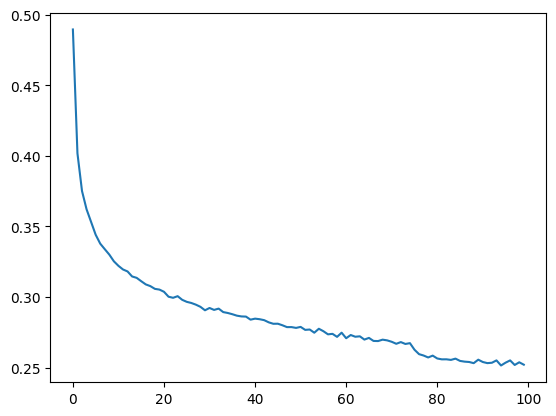

In [132]:
for layer in model.layers:
    layer.traning = False

calc_loss('train')
calc_loss('dev')

plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

<details><summary>💡 Solution — click to expand</summary>

With the architecture and the BatchNorm fix in place, scaling up is straightforward: increase the embedding dimension and hidden size. The same 3-level hierarchical structure now has much more capacity.

**Model definition:**
```python
torch.manual_seed(42)

n_embd = 24
n_hidden = 128

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2,  n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))  # ~76K
for p in parameters:
    p.requires_grad = True
```

Train with the same loop (200,000 steps, lr=0.1 → 0.01 at 150K), then evaluate and sample:

```python
# After training and setting layers to eval mode:
for layer in model.layers:
    layer.training = False

split_loss('train')
split_loss('val')

# Sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))
```

Expected results: **train ≈ 1.77, val ≈ 1.993**. The generated names should be noticeably more name-like than previous models.

</details>

---

## Part 7: Understanding Convolutions as Efficient Sliding

### Exercise 13: Convolutions as a For Loop

This exercise builds intuition for how convolutions relate to the hierarchical model we built. No code changes to the model are needed — this is a conceptual exercise with a small coding demonstration.

1. Pick a specific word from the training set (e.g., "deandre" which has 7 letters, producing 8 training examples).
2. Forward each of those 8 examples independently through the model using a for loop:
   ```python
   logits = torch.zeros(8, vocab_size)
   for i in range(8):
       logits[i] = model(Xtr[[start_idx + i]])
   ```
3. Observe that each call applies the same weights (the same "filter") at each position along the sequence. The only thing that changes is which slice of input the filter sees.
4. Explain that a 1D convolution does exactly this sliding operation, but:
   - The for loop is executed inside CUDA kernels, making it much faster.
   - Intermediate activations that are shared between overlapping receptive fields are computed only once and reused (e.g., the bigram representation of characters 3-4 is the right child of one tree and the left child of the next).
5. Relate back to the WaveNet diagram: the black tree is a single receptive field (what we implemented). The orange nodes show how the same computation is slid across the entire sequence, reusing shared intermediate nodes.

In [ ]:
# Exercise 13: Your code here


<details><summary>💡 Solution — click to expand</summary>

This exercise demonstrates that the hierarchical model, as we built it, processes one example at a time. A convolution would process all positions simultaneously.

```python
# Pick the word "deandre" — it starts at index 7 in the training set
for x, y in zip(Xtr[7:15], Ytr[7:15]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

# Forward a single example
logits = model(Xtr[[7]])  # note the double brackets to keep the batch dimension
print(logits.shape)  # torch.Size([1, 27])

# Forward all 8 examples of "deandre" independently
logits = torch.zeros(8, vocab_size)
for i in range(8):
    logits[i] = model(Xtr[[7 + i]])
print(logits.shape)  # torch.Size([8, 27])
```

Each of these 8 calls applies the exact same weight matrices (the same "filter") — only the input window shifts by one position. A 1D convolution formalizes this: it slides the filter over the input sequence in a single, parallelized operation. Benefits:
- The Python for-loop becomes a CUDA kernel — much faster.
- Intermediate computations shared between adjacent positions are computed once and reused. For example, the bigram representation of characters at positions 2-3 is used by both the tree rooted at position 3 and the tree rooted at position 4.

This is exactly what the WaveNet paper implements with its stack of dilated causal convolutions: each convolutional layer corresponds to one level of our tree, and the dilation factor doubles at each level (1, 2, 4) to match the hierarchical receptive field pattern.

</details>

---

## Part 8: Putting It All Together

### Exercise 14: Full Implementation Checklist

As a final exercise, create a single clean notebook cell (or a short script) that contains:
1. All layer class definitions (`Linear`, `BatchNorm1d`, `Tanh`, `Embedding`, `FlattenConsecutive`, `Sequential`).
2. Data loading and dataset construction with `block_size = 8`.
3. The scaled-up hierarchical model (`n_embd = 24`, `n_hidden = 128`).
4. The training loop (200,000 steps).
5. The evaluation function (with `layer.training = False`).
6. Sampling from the trained model.

Run it end-to-end and verify you achieve a validation loss near 1.99.

In [ ]:
# Exercise 14: Your code here


<details><summary>💡 Solution — click to expand</summary>

The complete performance log from the lecture:

| Configuration | Parameters | Train Loss | Val Loss |
|---|---|---|---|
| Original (block_size=3, n_hidden=200) | 12K | 2.058 | 2.105 |
| Flat, block_size=8, n_hidden=200 | 22K | 1.918 | 2.027 |
| Hierarchical, n_hidden=68 | 22K | 1.941 | 2.029 |
| + BatchNorm fix | 22K | 1.912 | 2.022 |
| Scaled up (n_embd=24, n_hidden=128) | 76K | 1.769 | 1.993 |

The full code is the combination of all answers above, assembled into a single runnable notebook. Refer to the reference notebook for the canonical version.

</details>